# CNN Classifier for MNIST Handwritten Digits

### Convolutional neural network built with TensorFlow 2 / Keras to classify the MNIST dataset.


## Libraries Imports and Load Dataset
![Image of datas](data/mnist.png)

In [2]:
#PACKAGES IMPORTS
import tensorflow as tf
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


### MNIST DATASET

This dataset have a training set of 60,0000 handwritten digits with corresponding labels and a test set of 10,000 images. 

### Load and preprocess the data

In [ ]:
mnist_data = tf.keras.datasets.mnist

(train_images, train_labels), (test_images, test_labels) = mnist_data.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
train_images[:2, :]

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(2, 28, 28), dtype=uint8)

In [ ]:
def scale_mnist_data(train_images, test_images):

    train_images = train_images/255.0
    test_images = test_images/255.0

    return(train_images, test_images)

In [9]:

scaled_train_images, scaled_test_images = scale_mnist_data(train_images, test_images)

In [14]:

scaled_train_images = scaled_train_images[..., np.newaxis]
scaled_test_images = scaled_test_images[..., np.newaxis]

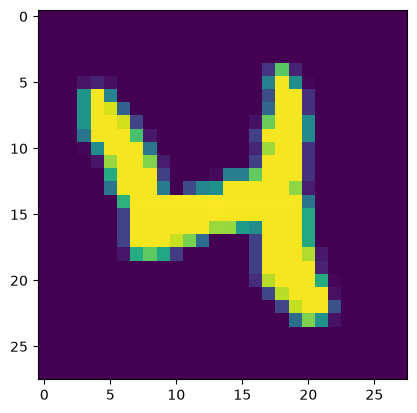

In [ ]:

idx = 20
image = scaled_train_images[idx]
plt.imshow(image)


### BUILD THE CONVOLUTIONAL NEURAL NETWORK MODEL



In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten

def get_model(input_shape):
    model = Sequential([
        Conv2D(8,(3,3), padding="SAME", activation='relu', input_shape=(input_shape)),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax'),
    ])

    return model

In [22]:

model = get_model(scaled_train_images[0].shape)

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,306 (411.35 KB)

 Trainable params: 105,306 (411.35 KB)

 Non-trainable params: 0 (0.00 B)

### COMPILE THE MODEL

In [30]:
def compile_model(model):
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [31]:
compile_model(model)

### FIT THE MODEL TO THE TRAINING DATA

In [32]:

def train_model(model, scaled_train_images, train_labels):

    history = model.fit(scaled_train_images, train_labels, epochs=5)

    return history

In [33]:
history = train_model(model, scaled_train_images, train_labels)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9391 - loss: 0.2103
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9758 - loss: 0.0787
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9827 - loss: 0.0557
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9863 - loss: 0.0420
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9893 - loss: 0.0326


### LEARNING CURVES

In [36]:

data_frame = pd.DataFrame(history.history)

In [37]:
data_frame

,accuracy,loss
0,0.939050,0.210325
1,0.975767,0.078709
2,0.982717,0.055684
3,0.986317,0.042035
4,0.989333,0.032631


Text(0, 0.5, 'Accuracy')

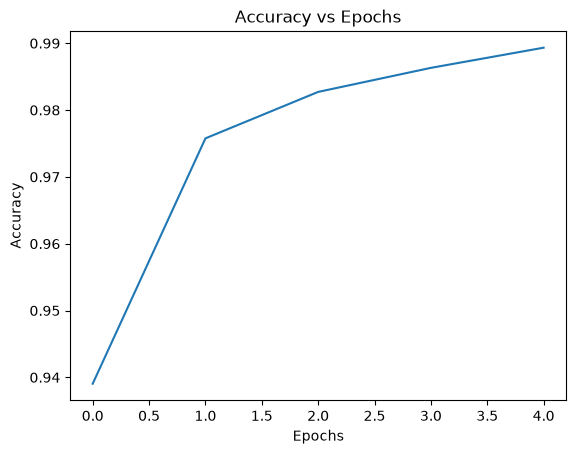

In [39]:

acc_plot = data_frame.plot(y='accuracy', title="Accuracy vs Epochs", legend=False)
acc_plot.set_xlabel("Epochs")
acc_plot.set_ylabel("Accuracy")

Text(0, 0.5, 'Accuracy')

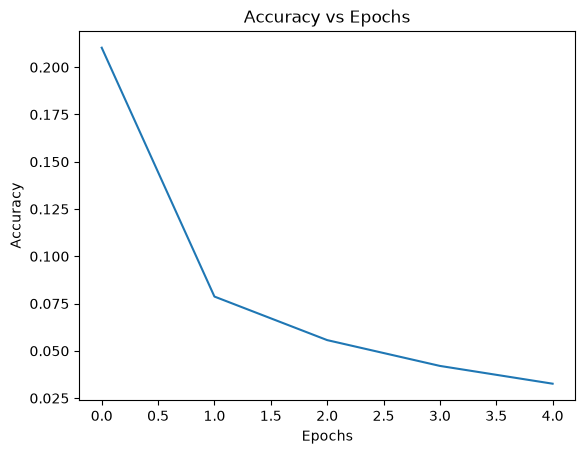

In [40]:

loss_plot = data_frame.plot(y='loss', title="Accuracy vs Epochs", legend=False)
loss_plot.set_xlabel("Epochs")
loss_plot.set_ylabel("Accuracy")

### EVALUATION MODEL

In [41]:

def evaluate_model(model, scaled_test_images, test_labels):

    test_loss, test_accuracy = model.evaluate(scaled_test_images, test_labels)

    return (test_loss, test_accuracy)

In [42]:

test_loss, test_accuracy = evaluate_model(model, scaled_test_images, test_labels)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step - accuracy: 0.9840 - loss: 0.0528
Test loss: 0.0528
Test accuracy: 0.9840
